In [74]:
from sklearn.datasets import load_diabetes

dataset = load_diabetes(return_X_y=False, as_frame=True, scaled=True)
dataset.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

age age in years

        sex

        bmi body mass index

        bp average blood pressure

        s1 tc, total serum cholesterol

        s2 ldl, low-density lipoproteins

        s3 hdl, high-density lipoproteins

        s4 tch, total cholesterol / HDL

        s5 ltg, possibly log of serum triglycerides level

        s6 glu, blood sugar level


In [75]:
df = dataset.data
target = dataset.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'bp'}>, <Axes: title={'center': 's1'}>,
        <Axes: title={'center': 's2'}>],
       [<Axes: title={'center': 's3'}>, <Axes: title={'center': 's4'}>,
        <Axes: title={'center': 's5'}>],
       [<Axes: title={'center': 's6'}>, <Axes: >, <Axes: >]], dtype=object)

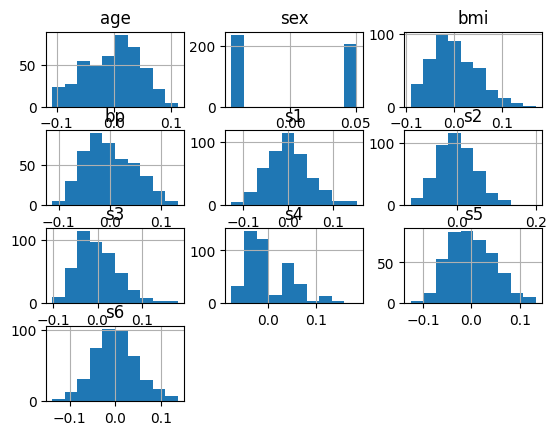

In [77]:
df.hist()

<Axes: >

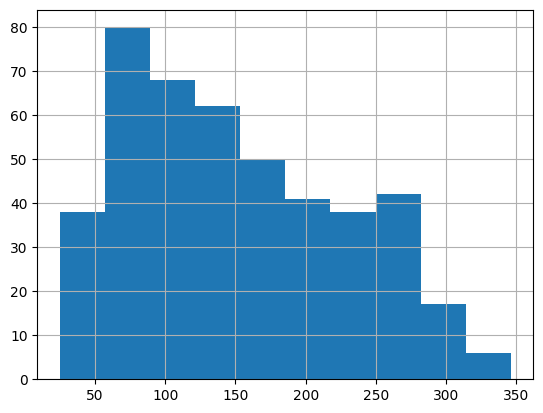

In [78]:
target.hist()

In [79]:
from sklearn.model_selection import train_test_split
import pandas as pd
df = pd.get_dummies(df, columns=["sex"], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.3, random_state=1276)

In [80]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoLars, LassoLarsCV, ElasticNetCV

linear = LinearRegression()
lasso = Lasso()
ridge = Ridge()
lars_a1 = LassoLars(alpha=0.5)
lars_a2 = LassoLars(alpha=0.1)
lars = LassoLarsCV()
elast = ElasticNetCV()

In [81]:
linear.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lars_a1.fit(X_train, y_train)
lars_a2.fit(X_train, y_train)
lars.fit(X_train, y_train)
elast.fit(X_train, y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.",0.5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [82]:
from sklearn.metrics import  root_mean_squared_error
y_linear = linear.predict(X_test)
y_lasso = lasso.predict(X_test)
y_ridge = ridge.predict(X_test)
y_lars1 = lars_a1.predict(X_test)
y_lars2 = lars_a2.predict(X_test)
y_larscv = lars.predict(X_test)
y_elast = elast.predict(X_test)

In [83]:
print(f"Linear: {root_mean_squared_error(y_test, y_linear)}, Lasso: {root_mean_squared_error(y_test, y_lasso)}, Ridge: {root_mean_squared_error(y_test, y_ridge)}")
print(f"Lars alpha=0.5: {root_mean_squared_error(y_test, y_lars1)}, Lars alpha=0.1: {root_mean_squared_error(y_test, y_lars2)}")
print(f"LarsCV: {root_mean_squared_error(y_test, y_larscv)}, ElasticNetCV: {root_mean_squared_error(y_test, y_elast)}")

Linear: 52.49501440685949, Lasso: 64.31744273925896, Ridge: 57.49015869408229
Lars alpha=0.5: 57.92673115690772, Lars alpha=0.1: 53.23989809549229
LarsCV: 52.84271888395224, ElasticNetCV: 55.50773260609327


In [84]:
lars.alpha_

np.float64(0.03526874186552531)

In [85]:
elast.l1_ratio

0.5

In [86]:
target.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [87]:
linear.feature_names_in_

array(['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'sex_0.05068011873981862'], dtype=object)